### Target Encoding ###

A target encoding is any kind of encoding that replaces a feature's categories with some number derived from the target.

A simple and effective version is to apply a group aggregation from Lesson 3, like the mean. Using the Automobiles dataset, this computes the average price of each vehicle's make:

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns

In [21]:
df = pd.read_csv("autos.csv")
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner
5,Maruti Alto LX BSIII,2007,140000,125000,Petrol,Individual,Manual,First Owner
6,Hyundai Xcent 1.2 Kappa S,2016,550000,25000,Petrol,Individual,Manual,First Owner
7,Tata Indigo Grand Petrol,2014,240000,60000,Petrol,Individual,Manual,Second Owner
8,Hyundai Creta 1.6 VTVT S,2015,850000,25000,Petrol,Individual,Manual,First Owner
9,Maruti Celerio Green VXI,2017,365000,78000,CNG,Individual,Manual,First Owner


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [23]:
#Frequency of brand cars / How many types of cars exist within quantities
name_list = df["name"].value_counts()
name_list.head(5)

name
Maruti Swift Dzire VDI    69
Maruti Alto 800 LXI       59
Maruti Alto LXi           47
Maruti Alto LX            35
Hyundai EON Era Plus      35
Name: count, dtype: int64

In [24]:
df["make_encoded"] = df.groupby("name")["selling_price"].transform("mean").round(2)
df[["name", "selling_price", "make_encoded"]]

,name,selling_price,make_encoded
0,Maruti 800 AC,60000,94347.83
1,Maruti Wagon R LXI Minor,135000,144416.67
2,Hyundai Verna 1.6 SX,600000,490666.40
3,Datsun RediGO T Option,250000,229999.86
4,Honda Amaze VX i-DTEC,450000,530555.56
...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),409999,370999.80
4336,Hyundai i20 Magna 1.4 CRDi,409999,409999.00
4337,Maruti 800 AC BSIII,110000,89000.00
4338,Hyundai Creta 1.6 CRDi SX Option,865000,1186666.67


In [25]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,make_encoded
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,94347.83
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,144416.67
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,490666.40
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,229999.86
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,530555.56
...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999,80000,Diesel,Individual,Manual,Second Owner,370999.80
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999,80000,Diesel,Individual,Manual,Second Owner,409999.00
4337,Maruti 800 AC BSIII,2009,110000,83000,Petrol,Individual,Manual,Second Owner,89000.00
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000,90000,Diesel,Individual,Manual,First Owner,1186666.67


This kind of target encoding is sometimes called a mean encoding. Applied to a binary target, it's also called bin counting. (Other names you might come across include: likelihood encoding, impact encoding, and leave-one-out encoding.)

### Smoothing ###

An encoding like this presents a couple of problems, however. First are unknown categories. Target encodings create a special risk of overfitting, which means they need to be trained on an independent "encoding" split. When you join the encoding to future splits, Pandas will fill in missing values for any categories not present in the encoding split. These missing values you would have to impute somehow.

Second are rare categories. When a category only occurs a few times in the dataset, any statistics calculated on its group are unlikely to be very accurate. In the Automobiles dataset, the mercurcy make only occurs once. The "mean" price we calculated is just the price of that one vehicle, which might not be very representative of any Mercuries we might see in the future. Target encoding rare categories can make overfitting more likely.

A solution to these problems is to add smoothing. The idea is to blend the in-category average with the overall average. Rare categories get less weight on their category average, while missing categories just get the overall average.

In pseudocode:

encoding = weight * in_category + (1 - weight) * overall

where weight is a value between 0 and 1 calculated from the category frequency.

An easy way to determine the value for weight is to compute an m-estimate:

weight = n / (n + m)

where n is the total number of times that category occurs in the data. The parameter m determines the "smoothing factor". Larger values of m put more weight on the overall estimate.

In [26]:
# Calculate the global mean (overall mean of 'selling_price')
global_mean = df['selling_price'].mean()

# Calculate the count and mean for each category (name)
category_stats = df.groupby('name')['selling_price'].agg(['mean', 'count'])

# Smoothing parameter (you can tune this value based on your needs)
smoothing_factor = 10  # A typical choice, but you can adjust this

# Apply the smoothing formula to get smoothed means
category_stats['smoothed_mean'] = (
    (category_stats['count'] * category_stats['mean']) + (smoothing_factor * global_mean)
) / (category_stats['count'] + smoothing_factor)

# Merge the smoothed means back into the original dataframe
df = df.merge(category_stats[['smoothed_mean']], left_on='name', right_index=True, how='left')

# Round the smoothed means to 2 decimal places
df['make_encoded'] = df['smoothed_mean'].round(2)

# Drop the temporary column for smoothed_mean
df = df.drop(columns='smoothed_mean')

# View the final DataFrame
print(df[['name', 'selling_price', 'make_encoded']])

                                     name  selling_price  make_encoded
0                           Maruti 800 AC          60000     218523.43
1                Maruti Wagon R LXI Minor         135000     250213.92
2                    Hyundai Verna 1.6 SX         600000     496050.76
3                  Datsun RediGO T Option         250000     391251.30
4                   Honda Amaze VX i-DTEC         450000     516645.95
...                                   ...            ...           ...
4335  Hyundai i20 Magna 1.4 CRDi (Diesel)         409999     459751.47
4336           Hyundai i20 Magna 1.4 CRDi         409999     495570.19
4337                  Maruti 800 AC BSIII         110000     333192.54
4338     Hyundai Creta 1.6 CRDi SX Option         865000     760079.57
4339                     Renault KWID RXT         225000     351170.10

[4340 rows x 3 columns]


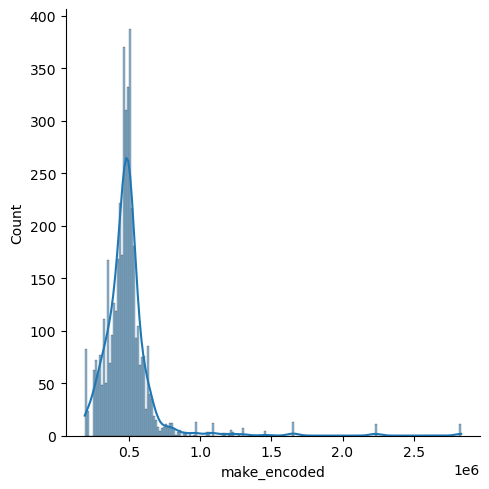

In [28]:
sns.displot(x = df["make_encoded"], kde = True)